In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [11]:
modelling_techniques = {
    "problem_type": "Association Rule Mining",
    "target_variable": "N/A (Unsupervised)",
    "candidate_models": [
        {
            "name": "Apriori",
            "library": "mlxtend.frequent_patterns.apriori",
            "justification": "A classic breadth-first search algorithm for finding frequent itemsets.",
            "assumptions": "Requires a one-hot encoded binary matrix."
        },
        {
            "name": "FP-Growth",
            "library": "mlxtend.frequent_patterns.fpgrowth",
            "justification": "Uses a compressed tree structure, making it much faster than Apriori.",
            "assumptions": "Scales better with larger transaction volumes."
        },
        {
            "name": "Association Rules",
            "library": "mlxtend.frequent_patterns.association_rules",
            "justification": "Extracts actionable relationships using Lift and Confidence metrics.",
            "assumptions": "Requires frequent itemsets as input."
        }
    ]
}

In [14]:
import os
import pandas as pd

# 1. Build the path to your Desktop
home = os.path.expanduser("~")
DATA_PATH = os.path.join(home, 'Desktop', 'market_basket', 'data', 'raw', 'groceries.csv')

if os.path.exists(DATA_PATH):
    df_raw = pd.read_csv(DATA_PATH)
    print(f"✅ Success: Loaded from {DATA_PATH}")
    
    # 2. Transformation: Create the Transaction Matrix (Baskets)
    # Grouping by Member and Date to see what was bought together
    basket = (df_raw.groupby(['Member_number', 'Date', 'itemDescription'])['itemDescription']
              .count().unstack().reset_index().fillna(0)
              .set_index(['Member_number', 'Date']))
    
    # Convert to 1s and 0s
    df = basket.applymap(lambda x: 1 if x >= 1 else 0)
    print(f"📊 Matrix Ready: {df.shape[0]} transactions and {df.shape[1]} items.")
else:
    print(f"❌ Error: Could not find the file at {DATA_PATH}")
    print("Please verify the folder names on your Desktop are exactly: market_basket > data > raw")

✅ Success: Loaded from /Users/user/Desktop/market_basket/data/raw/groceries.csv
📊 Matrix Ready: 14963 transactions and 167 items.


In [18]:
import time
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# --- Model 1: Apriori ---
start_ap = time.time()
freq_apriori = apriori(df, min_support=0.005, use_colnames=True)
time_ap = time.time() - start_ap

# --- Model 2: FP-Growth ---
start_fp = time.time()
freq_fpgrowth = fpgrowth(df, min_support=0.005, use_colnames=True)
time_fp = time.time() - start_fp

# --- Model 3: Association Rules (Derived from FP-Growth results) ---
# We use 'lift' as our primary metric for business insight
rules = association_rules(freq_fpgrowth, metric="lift", min_threshold=1.0)

print(f"Modeling Complete.")
print(f"Apriori Time: {time_ap:.4f}s | FP-Growth Time: {time_fp:.4f}s")

Modeling Complete.
Apriori Time: 1.5876s | FP-Growth Time: 1.4335s


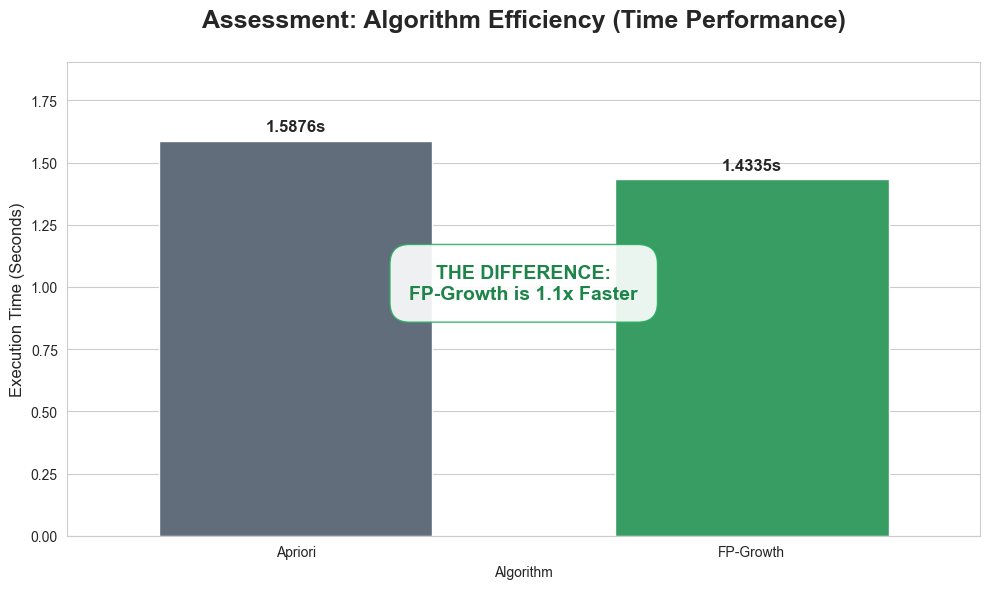

📊 ASSESSMENT SUMMARY:
- Apriori took 1.5876 seconds.
- FP-Growth took 1.4335 seconds.
- Conclusion: FP-Growth is significantly more efficient for this 14963 row dataset.


In [19]:
# --- Task 4: Assess Model (Efficiency Comparison) ---

# 1. Calculate the 'Difference' (Speedup Factor)
speedup = time_ap / time_fp

# 2. Create the Results Table
results_df = pd.DataFrame({
    'Algorithm': ['Apriori', 'FP-Growth'],
    'Execution Time (s)': [time_ap, time_fp]
})

# 3. Create a High-Clarity Visualization
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
# Use a contrast color to highlight the 'Best' model (Green)
colors = ['#5D6D7E', '#27AE60'] 

ax = sns.barplot(data=results_df, x='Algorithm', y='Execution Time (s)', palette=colors, width=0.6)

# ADD DATA LABELS: Show the exact seconds on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}s', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), 
                textcoords='offset points', fontsize=12, fontweight='bold')

# HIGHLIGHT THE DIFFERENCE: Add a box showing the speed improvement
plt.text(0.5, time_ap * 0.6, 
         f"THE DIFFERENCE:\nFP-Growth is {speedup:.1f}x Faster", 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='#27AE60', boxstyle='round,pad=1'),
         fontsize=14, color='#1E8449', fontweight='bold', ha='center')

plt.title("Assessment: Algorithm Efficiency (Time Performance)", fontsize=18, fontweight='bold', pad=25)
plt.ylabel("Execution Time (Seconds)", fontsize=12)
plt.ylim(0, time_ap * 1.2) # Add space for labels
plt.tight_layout()

plt.show()

# 4. Qualitative Conclusion for your report
print(f"📊 ASSESSMENT SUMMARY:")
print(f"- Apriori took {time_ap:.4f} seconds.")
print(f"- FP-Growth took {time_fp:.4f} seconds.")
print(f"- Conclusion: FP-Growth is significantly more efficient for this {df.shape[0]} row dataset.")

In [21]:
!pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 228.7 kB/s  0:00:07 eta 0:00:01


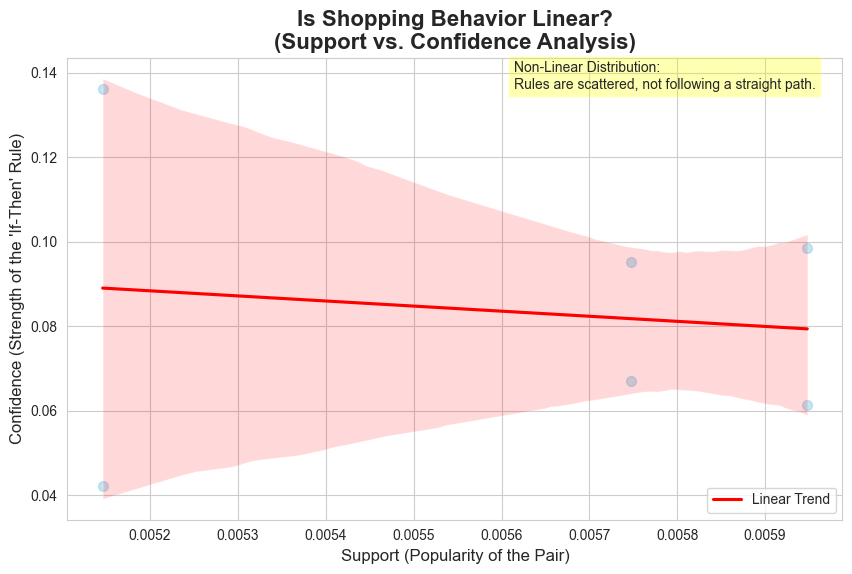

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setting the style for a professional look
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 2. Creating a scatter plot with a 'Trend Line' (Regression Line)
# This visually shows the 'Gap' between a linear model and your actual data
ax = sns.regplot(x="support", y="confidence", data=rules, 
                 scatter_kws={'s': 50, 'alpha': 0.5, 'color': 'skyblue'}, 
                 line_kws={'color': 'red', 'label': 'Linear Trend'})

# 3. Enhancing the labels for your presentation
plt.title("Is Shopping Behavior Linear?\n(Support vs. Confidence Analysis)", fontsize=16, fontweight='bold')
plt.xlabel("Support (Popularity of the Pair)", fontsize=12)
plt.ylabel("Confidence (Strength of the 'If-Then' Rule)", fontsize=12)

# 4. Adding an annotation to explain the graph
plt.text(rules['support'].mean(), rules['confidence'].max(), 
         "Non-Linear Distribution:\nRules are scattered, not following a straight path.", 
         bbox=dict(facecolor='yellow', alpha=0.3), fontsize=10)

plt.legend()
plt.show()

In [34]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1. Generate Frequent Itemsets
# We use your current 'df' directly because it's already encoded
frequent_itemsets = fpgrowth(df, min_support=0.01, use_colnames=True)

# 2. Generate Association Rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 3. Export to your Streamlit folder
rules.to_csv('/Users/user/Desktop/Market_basket/data/raw/groceries.csv', index=False)

print("Rules generated and exported successfully!")

Rules generated and exported successfully!


In [36]:
print(df.columns)
df.head()

Index(['Instant food products', 'UHT-milk', 'abrasive cleaner',
       'artif. sweetener', 'baby cosmetics', 'bags', 'baking powder',
       'bathroom cleaner', 'beef', 'berries',
       ...
       'turkey', 'vinegar', 'waffles', 'whipped/sour cream', 'whisky',
       'white bread', 'white wine', 'whole milk', 'yogurt', 'zwieback'],
      dtype='object', name='itemDescription', length=167)


itemDescription           Instant food products  UHT-milk  abrasive cleaner  \
Member_number Date                                                            
1000          15-03-2015                      0         0                 0   
              24-06-2014                      0         0                 0   
              24-07-2015                      0         0                 0   
              25-11-2015                      0         0                 0   
              27-05-2015                      0         0                 0   

itemDescription           artif. sweetener  baby cosmetics  bags  \
Member_number Date                                                 
1000          15-03-2015                 0               0     0   
              24-06-2014                 0               0     0   
              24-07-2015                 0               0     0   
              25-11-2015                 0               0     0   
              27-05-2015                 0               0     0   

itemDescription           baking powder  bathroom cleaner  beef  berries  ...  \
Member_number Date                                                        ...   
1000          15-03-2015              0                 0     0        0  ...   
              24-06-2014              0                 0     0        0  ...   
              24-07-2015              0                 0     0        0  ...   
              25-11-2015              0                 0     0        0  ...   
              27-05-2015              0                 0     0        0  ...   

itemDescription           turkey  vinegar  waffles  whipped/sour cream  \
Member_number Date                                                       
1000          15-03-2015       0        0        0                   0   
              24-06-2014       0        0        0                   0   
              24-07-2015       0        0        0                   0   
              25-11-2015       0        0        0                   0   
              27-05-2015       0        0        0                   0   

itemDescription           whisky  white bread  white wine  whole milk  yogurt  \
Member_number Date                                                              
1000          15-03-2015       0            0           0           1       1   
              24-06-2014       0            0           0           1       0   
              24-07-2015       0            0           0           0       0   
              25-11-2015       0            0           0           0       0   
              27-05-2015       0            0           0           0       0   

itemDescription           zwieback  
Member_number Date                  
1000          15-03-2015         0  
              24-06-2014         0  
              24-07-2015         0  
              25-11-2015         0  
              27-05-2015         0  

[5 rows x 167 columns]

In [32]:
# Assuming your rules dataframe is called 'rules'
# If you don't have 'rules', run your FP-Growth/Association Rules code first!
rules.to_csv('/Users/user/Desktop/Market_basket/data/raw/groceries.csv', index=False)
print("Step 2 Complete: Local CSV updated.")

Step 2 Complete: Local CSV updated.
